In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression

import numpy as np
import altair as alt
import warnings
from statsmodels.tsa.arima.model import ARIMA

print("Libraries imported successfully!")


Libraries imported successfully!


/tmp/ipython-input-528236307.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Year'] = df['Year'].fillna(method='ffill')


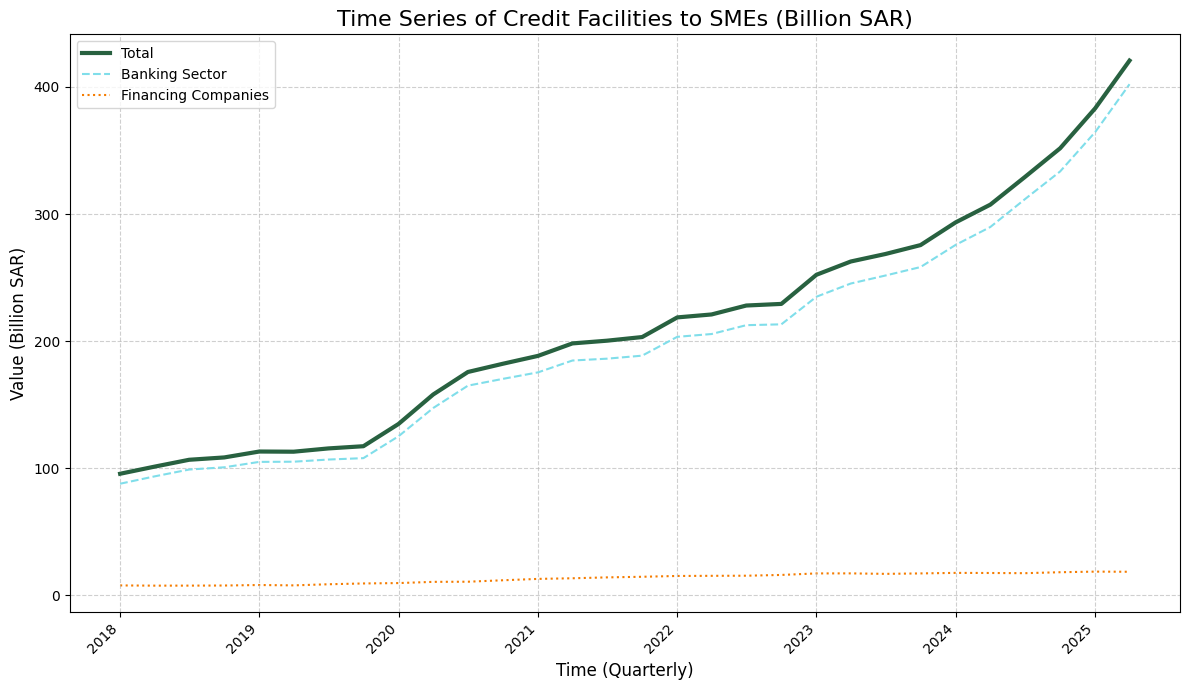

In [ ]:
# Data Cleaning and Preparation
file_name = "FundingsTotal.csv"
df = pd.read_csv(file_name, header=1)
df.columns = ['Year', 'Quarter', 'Banking Sector', 'Financing Companies', 'Total']
df['Year'] = df['Year'].fillna(method='ffill')

cols_to_convert = ['Banking Sector', 'Financing Companies', 'Total']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=cols_to_convert, inplace=True)
df['Year'] = df['Year'].astype(int)

# Calculation (Included for completeness)
V_start = df['Total'].iloc[0]
V_end = df['Total'].iloc[-1]
n = len(df) - 1
cqgr = (V_end / V_start)**(1/n) - 1

# Graph: Time Series Plot Preparation
df['Time_Str'] = df['Year'].astype(str) + df['Quarter'].str.replace('Q', 'Q')
df['Time_Index'] = pd.PeriodIndex(df['Time_Str'], freq='Q').to_timestamp()

#  Graph: Time Series Plot Generation (Arabic titles removed)
plt.figure(figsize=(12, 7))

# Plotting the three series with English-only labels
plt.plot(df['Time_Index'], df['Total'], label='Total', color='#286140', linewidth=3, zorder=3)
plt.plot(df['Time_Index'], df['Banking Sector'], label='Banking Sector', color='#80DEEA', linestyle='--', zorder=2)
plt.plot(df['Time_Index'], df['Financing Companies'], label='Financing Companies', color='#F57C00', linestyle=':', zorder=1)

# Adding English-only titles and labels
plt.title('Time Series of Credit Facilities to SMEs (Billion SAR)', fontsize=16)
plt.xlabel('Time (Quarterly)', fontsize=12)
plt.ylabel('Value (Billion SAR)', fontsize=12)

# Customizing the X-axis
years = df['Year'].unique()
year_ticks = [pd.to_datetime(f'{y}-01-01') for y in years]
num_year_ticks = mdates.date2num(year_ticks)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(num_year_ticks))
plt.xticks(rotation=45, ha='right')

# Adding a legend
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the figure
plt.savefig('sme_credit_facilities_time_series_english_only.png')

/tmp/ipython-input-2839351447.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Year'] = df['Year'].fillna(method='ffill')


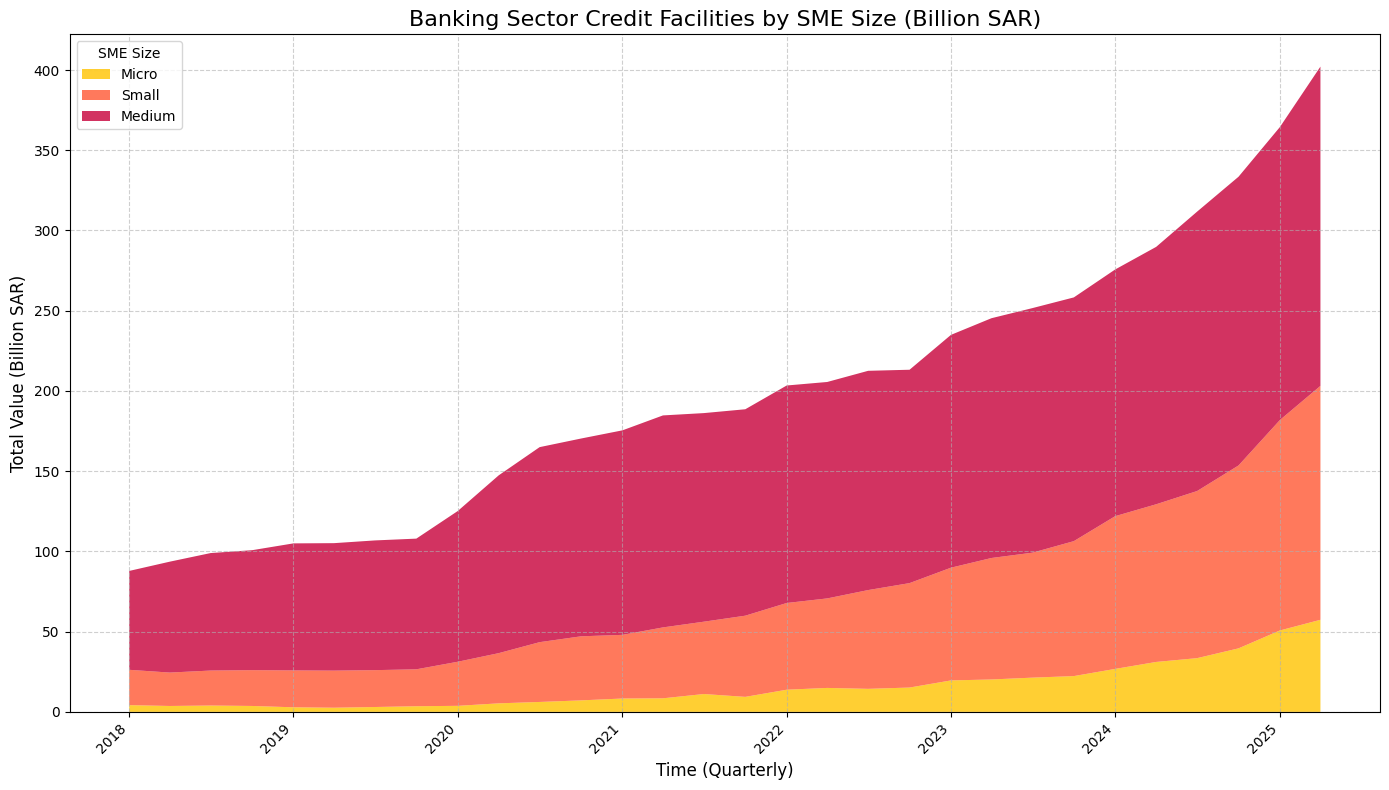

In [ ]:

#  Cleaning and Preparation
file_name = "banking sector.csv"
df = pd.read_csv(file_name, header=1)

df.columns = ['Year', 'Quarter', 'Micro', 'Small', 'Medium', 'Total']

# Forward-fill the 'Year' column
df['Year'] = df['Year'].fillna(method='ffill')

# Define columns that contain numeric values
cols_to_convert = ['Micro', 'Small', 'Medium', 'Total']

# Convert numeric columns to float and drop non-numeric rows
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=cols_to_convert, inplace=True)

# Convert Year column from float to integer
df['Year'] = df['Year'].astype(int)

# Create a Time Index for plotting
df['Time_Str'] = df['Year'].astype(str) + df['Quarter'].str.replace('Q', 'Q')
df['Time_Index'] = pd.PeriodIndex(df['Time_Str'], freq='Q').to_timestamp()

# Define the SME size segments
segments = ['Micro', 'Small', 'Medium']
colors = ['#FFC300', '#FF5733', '#C70039']

# Visualization: Stacked Area Chart Code

plt.figure(figsize=(14, 8))

# Create the stacked area chart
plt.stackplot(
    df['Time_Index'],
    [df[seg] for seg in segments],
    labels=segments,
    colors=colors,
    alpha=0.8
)

# Formatting and Labels
plt.title('Banking Sector Credit Facilities by SME Size (Billion SAR)', fontsize=16)
plt.xlabel('Time (Quarterly)', fontsize=12)
plt.ylabel('Total Value (Billion SAR)', fontsize=12)

# Customizing X-axis to show years
years = df['Year'].unique()
year_ticks = [pd.to_datetime(f'{y}-01-01') for y in years]
num_year_ticks = mdates.date2num(year_ticks)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(num_year_ticks))
plt.xticks(rotation=45, ha='right')

plt.legend(loc='upper left', title="SME Size")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig('sme_credit_facilities_by_size_stacked_area.png')

/tmp/ipython-input-588240166.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Year'] = df['Year'].fillna(method='ffill')


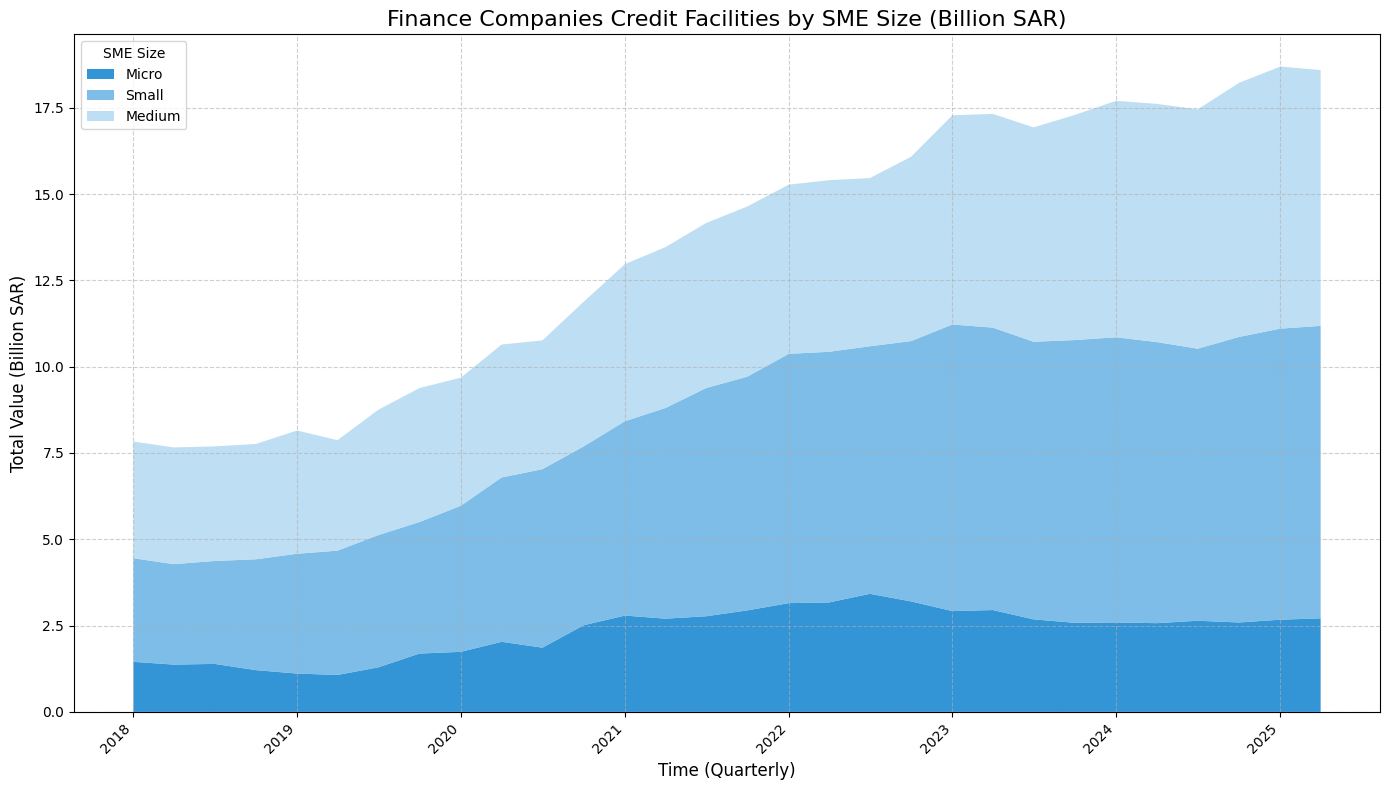

In [ ]:
# Data Cleaning and Preparation
file_name = "finance companies.csv"
# Load the data, setting the second row (index 1) as the header
df = pd.read_csv(file_name, header=1)

# Rename the columns based on the inspection:
df.columns = ['Year', 'Quarter', 'Micro', 'Small', 'Medium', 'Total']

# Forward-fill the 'Year' column
df['Year'] = df['Year'].fillna(method='ffill')

# Define columns that contain numeric values
cols_to_convert = ['Micro', 'Small', 'Medium', 'Total']

# Convert numeric columns to float and drop non-numeric rows
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=cols_to_convert, inplace=True)

# Convert Year column from float to integer
df['Year'] = df['Year'].astype(int)

# Create a Time Index for plotting
df['Time_Str'] = df['Year'].astype(str) + df['Quarter'].str.replace('Q', 'Q')
df['Time_Index'] = pd.PeriodIndex(df['Time_Str'], freq='Q').to_timestamp()

# Define the SME size segments
segments = ['Micro', 'Small', 'Medium']
colors = ['#007ACC', '#5DADE2', '#AED6F1']

# Visualization: Stacked Area Chart Code

plt.figure(figsize=(14, 8))

# Create the stacked area chart
plt.stackplot(
    df['Time_Index'],
    [df[seg] for seg in segments],
    labels=segments,
    colors=colors,
    alpha=0.8
)

# Formatting and Labels
plt.title('Finance Companies Credit Facilities by SME Size (Billion SAR)', fontsize=16)
plt.xlabel('Time (Quarterly)', fontsize=12)
plt.ylabel('Total Value (Billion SAR)', fontsize=12)

# Customizing X-axis to show years
years = df['Year'].unique()
year_ticks = [pd.to_datetime(f'{y}-01-01') for y in years]
num_year_ticks = mdates.date2num(year_ticks)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(num_year_ticks))
plt.xticks(rotation=45, ha='right')

plt.legend(loc='upper left', title="SME Size")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig('finance_companies_by_size_stacked_area.png')

Final Pivot Table (Percentage Contribution):
Enterprise Size      Micro      Small     Medium
Year                                            
2019             27.424479  25.989185  46.586335
2020             27.410798  25.351296  47.237906
2021             27.766101  26.066511  46.167389
2022             26.486920  26.222596  47.290484
2023             26.569930  26.353922  47.076148


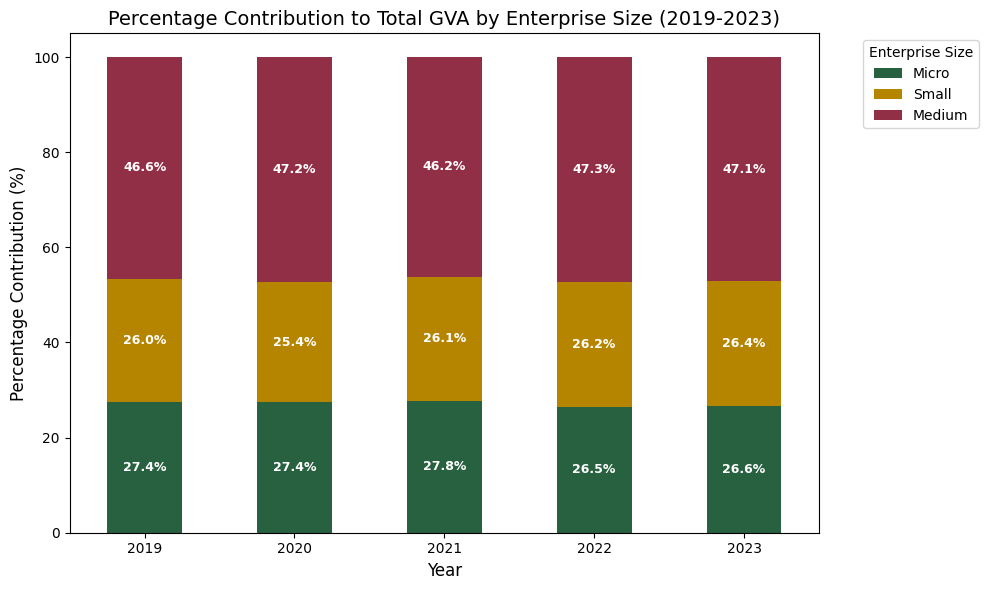

In [ ]:
# Years and their corresponding column suffixes based on the data structure
year_suffixes = {
    2019: '',
    2020: '.1',
    2021: '.2',
    2022: '.3',
    2023: '.4'
}
enterprise_sizes = ['Micro', 'Small', 'Medium']

# Initialize an empty list to store GVA data for all years
gva_data = []

# Data Loading and Cleaning
# Load the data with the correct header (row 2, index 1)
df = pd.read_csv('VS.csv', header=1)

# Drop the first row (index 0) which is a completely NaN row or a separator row
df = df.drop(0).reset_index(drop=True)

# Iterate through each year to process and aggregate data
for year, suffix in year_suffixes.items():
    # Identify the column names for the current year (e.g., 'Micro Establishments.1')
    cols_to_select = [f'{size} Establishments{suffix}' for size in enterprise_sizes]

    # Select and clean the data
    df_gva_year = df[cols_to_select].copy()

    for col in cols_to_select:
        # Remove commas and convert to numeric, coercing errors to NaN
        df_gva_year[col] = pd.to_numeric(
            df_gva_year[col].astype(str).str.replace(',', ''), errors='coerce'
        )

    # Calculation: Aggregate and Find Percentage Contribution
    # Aggregate GVA for the year (summing across all economic activities)
    gva_agg_year = df_gva_year.sum(axis=0)

    # Calculate total GVA for the year (sum of Micro, Small, Medium)
    total_gva = gva_agg_year.sum()

    # Calculate percentage contribution for each size
    for size in enterprise_sizes:
        col_name = f'{size} Establishments{suffix}'
        # Calculate contribution percentage
        contribution = (gva_agg_year[col_name] / total_gva) * 100

        gva_data.append({
            'Year': year,
            'Enterprise Size': size,
            'Contribution (%)': contribution
        })

# Create the final DataFrame for plotting
df_plot = pd.DataFrame(gva_data)

# Pivot the data for the stacked bar chart
df_pivot = df_plot.pivot(index='Year', columns='Enterprise Size', values='Contribution (%)')

# Visualization: Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Define plotting order and colors
plot_order = ['Micro', 'Small', 'Medium']
df_pivot = df_pivot[plot_order]
colors = ['#286140', '#B58500', '#912F46'] # Distinct colors for the three sizes

df_pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)

# Add labels and title
ax.set_title('Percentage Contribution to Total GVA by Enterprise Size (2019-2023)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage Contribution (%)', fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Add contribution percentages on the bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        # Only label values > 0.5%
        if height > 0.5:
            x = bar.get_x() + bar.get_width() / 2.0
            y = bar.get_y() + height / 2.0
            ax.text(x, y, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Place the legend outside the plot
ax.legend(title='Enterprise Size', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()

plt.savefig('gva_contribution_stacked_bar_2019_2023.png')

print("Final Pivot Table (Percentage Contribution):")
print(df_pivot)

In [ ]:
# Load and Process Data (2019-2023)
df = pd.read_csv('VS.csv', header=1)
df_cleaned = df.iloc[1:].copy()

years = [2019, 2020, 2021, 2022, 2023]
df_list = []
base_cols = ['Economic Activity', 'Micro', 'Small', 'Medium']

for i, year in enumerate(years):
    suffix = f'.{i}' if i > 0 else ''
    year_cols = [
        f'Economic activity{suffix}',
        f'Micro Establishments{suffix}',
        f'Small Establishments{suffix}',
        f'Medium Establishments{suffix}'
    ]

    try:
        df_year = df_cleaned[year_cols].copy()
    except KeyError:
        continue

    df_year.columns = base_cols
    df_year['Year'] = year
    df_list.append(df_year)

df_combined = pd.concat(df_list, ignore_index=True)

df_melted = df_combined.melt(
    id_vars=['Year', 'Economic Activity'],
    value_vars=['Micro', 'Small', 'Medium'],
    var_name='Enterprise Size',
    value_name='GVA (SAR)'
)

# Robust cleaning of GVA column and calculation
df_melted['GVA (SAR)'] = (
    df_melted['GVA (SAR)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('%', '', regex=False)
)
df_melted['GVA (SAR)'] = pd.to_numeric(df_melted['GVA (SAR)'], errors='coerce')

df_final = df_melted.dropna(subset=['GVA (SAR)', 'Economic Activity']).copy()

# Remove summary rows
summary_rows = [act for act in df_final['Economic Activity'].unique() if 'total' in str(act).lower() or 'memo' in str(act).lower() or 'all activities' in str(act).lower()]
df_final = df_final[~df_final['Economic Activity'].isin(summary_rows)].copy()

# Calculate Percentage Contribution and Merge Totals
df_total_gva_per_year = df_final.groupby('Year')['GVA (SAR)'].sum().reset_index(name='Total GVA per Year (SAR)')
df_result = pd.merge(df_final, df_total_gva_per_year, on='Year', how='left')
df_result['GDP Contribution %'] = (df_result['GVA (SAR)'] / df_result['Total GVA per Year (SAR)']) * 100

df_overall_total_gva = df_result.groupby('Economic Activity')['GVA (SAR)'].sum().reset_index(name='Overall Total GVA')
df_chart = pd.merge(df_result, df_overall_total_gva, on='Economic Activity', how='left')


# Generate Visualization
chart = alt.Chart(df_chart).mark_bar().encode(
    # X-axis: Economic Activity, sorted by Overall Total GVA
    x=alt.X('Economic Activity', sort=alt.EncodingSortField(field='Overall Total GVA', op='sum', order='descending'), title='Economic Activity'),
    # Y-axis: Sum of Percentage Contribution
    y=alt.Y('sum(GDP Contribution %)', title='GDP Contribution % (of Total Economy GVA)', axis=alt.Axis(format='.1f', titlePadding=10)),
    # Color: Stacked by Enterprise Size
    color=alt.Color('Enterprise Size', title='Enterprise Size', sort=['Micro', 'Small', 'Medium']),
    # Columns: Separate charts for each Year (Facet)
    column=alt.Column('Year:O', header=alt.Header(titleOrient='bottom', labelOrient='bottom'), title='Year'),
    # Tooltip
    tooltip=[
        alt.Tooltip('Economic Activity'),
        alt.Tooltip('Enterprise Size'),
        alt.Tooltip('Year:N'),
        alt.Tooltip('sum(GDP Contribution %)', format='.2f', title='GDP Contribution %')
    ]
).properties(
    title='GDP Contribution Percentage by Economic Activity and Enterprise Size (2019 - 2023)'
).interactive()

# Save the chart
chart.save('gdp_contribution_percentage_stacked_bar.json')

# Output the chart object itself to ensure visualization in the environment
chart

alt.Chart(...)

<>:84: SyntaxWarning: invalid escape sequence '\%'
<>:106: SyntaxWarning: invalid escape sequence '\%'
<>:84: SyntaxWarning: invalid escape sequence '\%'
<>:106: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipython-input-2737024469.py:84: SyntaxWarning: invalid escape sequence '\%'
  ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}\%'))
/tmp/ipython-input-2737024469.py:106: SyntaxWarning: invalid escape sequence '\%'
  df_summary['Contribution (%)'] = df_summary['Contribution Value'].round(2).apply(lambda x: f'{x}\%')


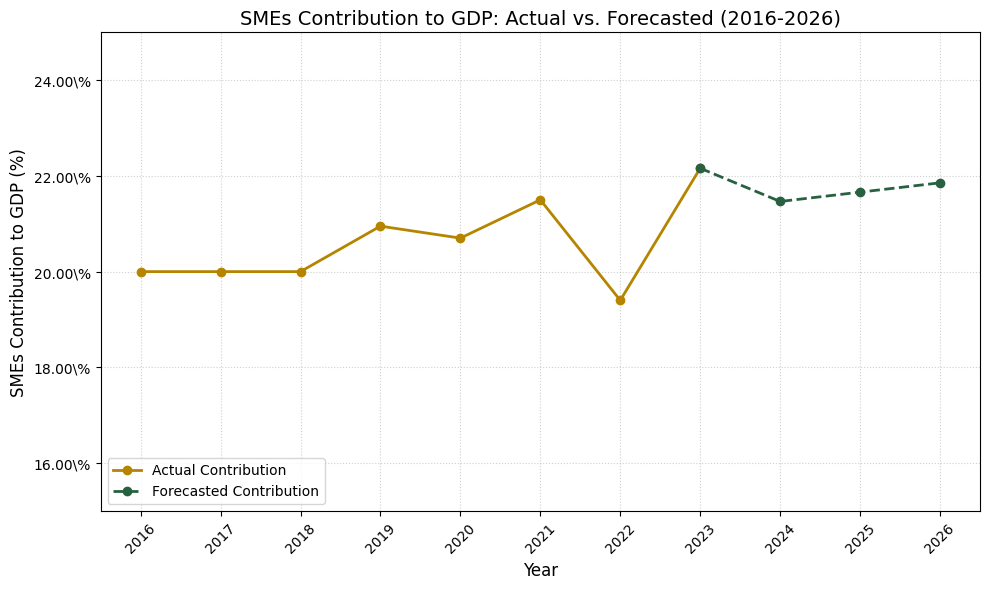


--- Summary of Actual and Forecasted Contribution (2016-2026) ---
| Year   | Type     | Contribution (%)   |
|:-------|:---------|:-------------------|
| 2016   | Actual   | 20.0\%             |
| 2017   | Actual   | 20.0\%             |
| 2018   | Actual   | 20.0\%             |
| 2019   | Actual   | 20.95\%            |
| 2020   | Actual   | 20.7\%             |
| 2021   | Actual   | 21.5\%             |
| 2022   | Actual   | 19.4\%             |
| 2023   | Actual   | 22.16\%            |
| 2024   | Forecast | 21.47\%            |
| 2025   | Forecast | 21.66\%            |
| 2026   | Forecast | 21.86\%            |


In [ ]:
# Data Loading and Cleaning

# Load data from the specified file
df = pd.read_csv('VSVS(LIne).csv', header=1)

# Data Cleaning
df_cleaned = df.dropna(subset=['Year']).copy()
df_cleaned.rename(columns={'SMEs Contribution  to GDP ': 'Actual Contribution'}, inplace=True)
df_cleaned['Actual Contribution'] = df_cleaned['Actual Contribution'].astype(str).str.replace('%', '').astype(float)
df_cleaned['Year'] = df_cleaned['Year'].astype(int)

# Identify last actual year and value
last_actual_year = df_cleaned['Year'].max()
last_actual_value = df_cleaned['Actual Contribution'].iloc[-1]

# Forecasting

# Years to forecast (2024, 2025, 2026)
forecast_years = np.array([2024, 2025, 2026])

# Prepare data for Linear Regression (using RAW data)
X = df_cleaned['Year'].values.reshape(-1, 1)
y = df_cleaned['Actual Contribution'].values

# Train the model
model = LinearRegression()
model.fit(X, y)

X_forecast = forecast_years.reshape(-1, 1)

# Generate the forecast
forecasted_contribution = model.predict(X_forecast)

# Prepare Final Plotting Data

# Forecast Line (starts from the LAST ACTUAL point)
forecast_line = pd.DataFrame({
    'Year': [last_actual_year] + list(forecast_years),
    'Forecasted Contribution': [last_actual_value] + list(forecasted_contribution)
})

# Generate the Line Graph

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot 1: Actual Contribution (Color: #B58500)
plt.plot(
    df_cleaned['Year'],
    df_cleaned['Actual Contribution'],
    marker='o',
    linestyle='-',
    color='#B58500',
    linewidth=2,
    label='Actual Contribution'
)

# Plot 2: Forecasted Contribution (Color: #286140)
plt.plot(
    forecast_line['Year'],
    forecast_line['Forecasted Contribution'],
    marker='o',
    linestyle='--',
    color='#286140',
    linewidth=2,
    label='Forecasted Contribution'
)

# Annotations and Labels
plt.title('SMEs Contribution to GDP: Actual vs. Forecasted (2016-2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SMEs Contribution to GDP (%)', fontsize=12)

# Set Y-axis range from 15% to 25%
plt.ylim(15.0, 25.0)

# Format Y-axis numbers to include the percent sign
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}\%'))

all_years = np.concatenate([df_cleaned['Year'].unique(), forecast_years])
plt.xticks(all_years, rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()

# You can uncomment this line to save the plot if running in your environment
# plt.savefig('sme_gdp_raw_forecast_15_to_25_percent.png')
plt.show() # Use plt.show() in a local environment to display the plot

# Summary

df_summary = pd.DataFrame({
    'Year': np.concatenate([df_cleaned['Year'], forecast_years]),
    'Contribution Value': np.concatenate([df_cleaned['Actual Contribution'], forecasted_contribution]),
})

df_summary.loc[df_summary['Year'] <= last_actual_year, 'Type'] = 'Actual'
df_summary.loc[df_summary['Year'] > last_actual_year, 'Type'] = 'Forecast'

df_summary['Contribution (%)'] = df_summary['Contribution Value'].round(2).apply(lambda x: f'{x}\%')

df_final_table = df_summary[['Year', 'Type', 'Contribution (%)']].copy()

print("\n--- Summary of Actual and Forecasted Contribution (2016-2026) ---")
print(df_final_table.to_markdown(index=False, numalign="left", stralign="left"))

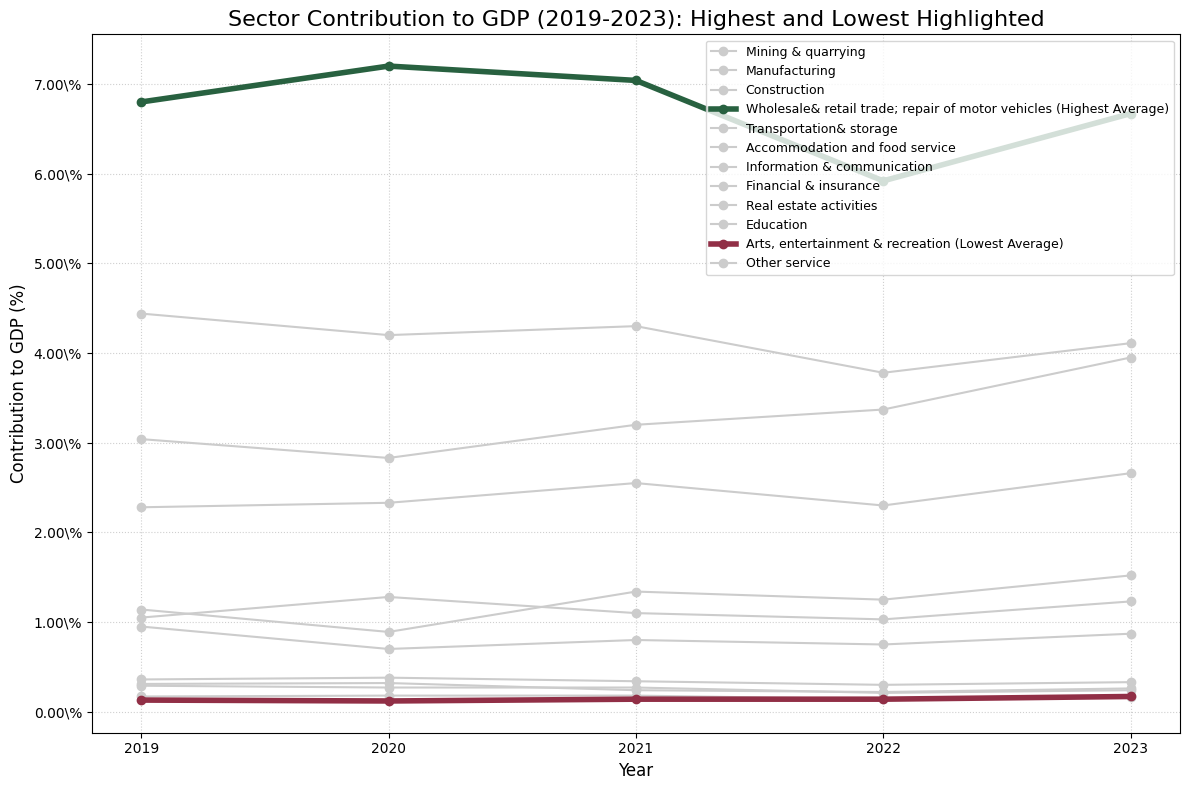

In [20]:
# Data Loading and Cleaning (Wide to Long)
df = pd.read_csv('sectorGDP.csv', header=1)

# Define column groups and years based on the file structure
col_map = {
    2019: [0, 1], 2020: [3, 4], 2021: [6, 7], 2022: [9, 10], 2023: [12, 13]
}

df_list = []
col_names = df.columns
for year, indices in col_map.items():
    activity_col = col_names[indices[0]]
    contribution_col = col_names[indices[1]]
    df_temp = df[[activity_col, contribution_col]].copy()
    df_temp.columns = ['Sector', 'Contribution']
    df_temp['Year'] = year
    df_list.append(df_temp)

df_long = pd.concat(df_list, ignore_index=True)

# Clean Sector and Contribution data
df_long['Sector'] = df_long['Sector'].astype(str).str.strip().str.replace('\n', ' ').str.replace('\r', ' ').str.replace('\"', '', regex=False)
df_long['Contribution'] = df_long['Contribution'].astype(str).str.replace('%', '', regex=False).str.strip()
df_long['Contribution'] = pd.to_numeric(df_long['Contribution'], errors='coerce')

# Drop NaNs and EXCLUDE 'Total' row (and other non-sector rows)
excluded_sectors = ['economic activity', 'nan', 'total']
df_cleaned = df_long.dropna(subset=['Contribution']).copy()
df_cleaned = df_cleaned[~df_cleaned['Sector'].str.lower().isin(excluded_sectors)].copy()


# Identify Highest and Lowest Sectors
sector_means = df_cleaned.groupby('Sector')['Contribution'].mean()
highest_sector = sector_means.idxmax()
lowest_sector = sector_means.idxmin()


# Define New Color Scheme for Highlighting
HIGHLIGHT_HIGH = '#286140'
HIGHLIGHT_LOW = '#912F46'

color_map_user = {
    'Wholesale& retail trade; repair of motor vehicles': '#286140',
    'Arts, entertainment & recreation': '#912F46',
    'Mining & quarrying': '#FFC4EB',
    'Manufacturing': '#ABC798',
    'Construction': '#FFC857',
    'Transportation& storage': '#4EAD4',
    'Accommodation and food service': '#FFBA49',
    'Information & communication': '#20A39E',
    'Financial & insurance': '#A4A9AD',
    'Real estate activities': '#588B8B',
    'Education': '#F28F3B',
    'Other service activities': '#341C1C'
}

# Generate the Line Graph (Custom Colors and Bolding)
plt.figure(figsize=(12, 8))
ax = plt.gca()

for sector in df_cleaned['Sector'].unique():
    sector_data = df_cleaned[df_cleaned['Sector'] == sector].sort_values('Year')

    line_width = 1.5
    zorder = 2
    color = DESATURATED_REST
    label = sector

    if sector == highest_sector:
        color = HIGHLIGHT_HIGH
        line_width = 4
        zorder = 3
        label = f'{sector} (Highest Average)'
    elif sector == lowest_sector:
        color = HIGHLIGHT_LOW
        line_width = 4
        zorder = 3
        label = f'{sector} (Lowest Average)'

    plt.plot(
        sector_data['Year'],
        sector_data['Contribution'],
        marker='o',
        linestyle='-',
        linewidth=line_width,
        color=color,
        zorder=zorder,
        label=label
    )

# Annotations and Labels
plt.title('Sector Contribution to GDP (2019-2023): Highest and Lowest Highlighted', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Contribution to GDP (%)', fontsize=12)

# Format Y-axis numbers to include the percent sign
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}\%'))
plt.xticks(df_cleaned['Year'].unique())
plt.grid(True, linestyle=':', alpha=0.6)

# Legend in the top right corner with one column (as requested)
plt.legend(loc='upper right', ncol=1, fontsize=9)
plt.tight_layout()

# The image file is saved as 'sector_gdp_contribution_highlighted_new_colors.png'
plt.savefig('sector_gdp_contribution_highlighted_new_colors.png')

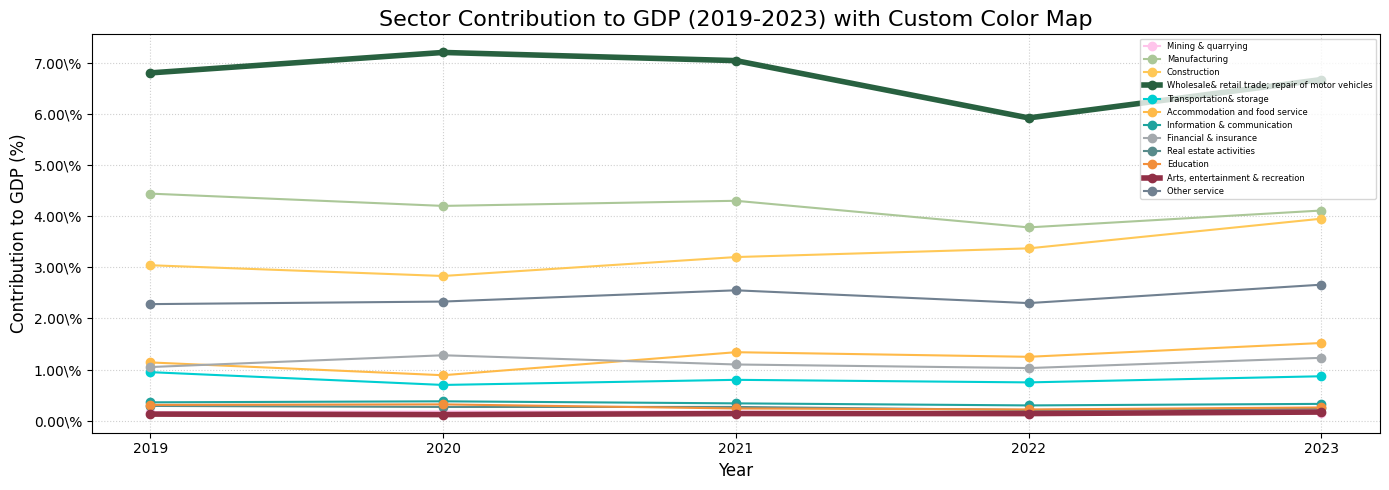

In [26]:
# Data Loading and Cleaning (Wide to Long)
df = pd.read_csv('sectorGDP.csv', header=1)

col_map = {
    2019: [0, 1], 2020: [3, 4], 2021: [6, 7], 2022: [9, 10], 2023: [12, 13]
}

df_list = []
col_names = df.columns
for year, indices in col_map.items():
    activity_col = col_names[indices[0]]
    contribution_col = col_names[indices[1]]
    df_temp = df[[activity_col, contribution_col]].copy()
    df_temp.columns = ['Sector', 'Contribution']
    df_temp['Year'] = year
    df_list.append(df_temp)

df_long = pd.concat(df_list, ignore_index=True)

# Clean Sector and Contribution data
df_long['Sector'] = df_long['Sector'].astype(str).str.strip().str.replace('\n', ' ').str.replace('\r', ' ').str.replace('\"', '', regex=False)
df_long['Contribution'] = df_long['Contribution'].astype(str).str.replace('%', '', regex=False).str.strip()
df_long['Contribution'] = pd.to_numeric(df_long['Contribution'], errors='coerce')

# Drop NaNs and EXCLUDE 'Total' row (and other non-sector rows)
excluded_sectors = ['economic activity', 'nan', 'total']
df_cleaned = df_long.dropna(subset=['Contribution']).copy()
df_cleaned = df_cleaned[~df_cleaned['Sector'].str.lower().isin(excluded_sectors)].copy()


# Define Custom Color Map and Highlighting Logic

color_map_user = {
    'Wholesale& retail trade; repair of motor vehicles': '#286140',
    'Arts, entertainment & recreation': '#912F46',
    'Mining & quarrying': '#FFC4EB',
    'Manufacturing': '#ABC798',
    'Construction': '#FFC857',
    'Transportation& storage': '#4EAD4',
    'Accommodation and food service': '#FFBA49',
    'Information & communication': '#20A39E',
    'Financial & insurance': '#A4A9AD',
    'Real estate activities': '#588B8B',
    'Education': '#F28F3B',
    'Other service activities': '#341C1C'
}

# Invalid color substitution
invalid_color = '#4EAD4'
valid_color_substitute = '#00CED1' # Dark Turquoise


# Sectors to be BOLDED (as requested by the user)
bold_sectors = [
    'Wholesale& retail trade; repair of motor vehicles',
    'Arts, entertainment & recreation'
]

# Generate the Line Graph (Custom Colors and Bolding)

# Setting figsize based on user request (interpreting points as inches)
plt.figure(figsize=(14, 5))
ax = plt.gca()

for sector in df_cleaned['Sector'].unique():
    sector_data = df_cleaned[df_cleaned['Sector'] == sector].sort_values('Year')

    #
    line_width = 1.5
    zorder = 2

    if sector in bold_sectors:
        line_width = 4
        zorder = 3

    # Determine Color
    color = color_map_user.get(sector, '#708090')


    if color == invalid_color:
        color = valid_color_substitute

    plt.plot(
        sector_data['Year'],
        sector_data['Contribution'],
        marker='o',
        linestyle='-',
        linewidth=line_width,
        color=color,
        zorder=zorder,
        label=sector
    )

# Annotations and Labels
plt.title('Sector Contribution to GDP (2019-2023) with Custom Color Map', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Contribution to GDP (%)', fontsize=12)

# Format Y-axis numbers to include the percent sign
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}\%'))
plt.xticks(df_cleaned['Year'].unique())
plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(loc='upper right', ncol=1, fontsize=6)
plt.tight_layout()

plt.savefig('sector_gdp_contribution_full_custom_colors_bolded_resized.png')

In [6]:
# Data Loading and Cleaning

# Load data
df = pd.read_csv('VSVS(LIne).csv', header=1)

# Data Cleaning
contribution_col = [col for col in df.columns if 'SMEs Contribution' in col][0]

df_analysis = df.dropna(subset=['Year', contribution_col]).copy()
df_analysis.rename(columns={contribution_col: 'Actual Contribution'}, inplace=True)

# Clean
df_analysis['Actual Contribution'] = df_analysis['Actual Contribution'].astype(str).str.replace('%', '').astype(float)

# Convert
df_analysis['Year'] = df_analysis['Year'].astype(int)

# Correlation Analysis

correlation = df_analysis['Year'].corr(df_analysis['Actual Contribution'])

#Linear Regression Analysis

# Prepare data for Linear Regression
X = df_analysis['Year'].values.reshape(-1, 1)
y = df_analysis['Actual Contribution'].values

# Train the model
model = LinearRegression()
model.fit(X, y)

# Extract results
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Output Results

print("--- Correlation and Regression Analysis ---")
print(f"Correlation Coefficient (Year vs. Contribution): {correlation:.4f}")
print("\n--- Linear Regression Model ---")
print(f"Regression Equation: Y = {slope:.4f} * Year + {intercept:.4f}")
print(f"R-squared (Coefficient of Determination): {r_squared:.4f}")

--- Correlation and Regression Analysis ---
Correlation Coefficient (Year vs. Contribution): 0.5202

--- Linear Regression Model ---
Regression Equation: Y = 0.1949 * Year + -372.9733
R-squared (Coefficient of Determination): 0.2706



--- Summary of ARIMA Forecasted Contribution (2024-2025) ---
| Year   | Forecasted Contribution (%)   | 95% Lower Bound (%)   | 95% Upper Bound (%)   |
|:-------|:------------------------------|:----------------------|:----------------------|
| 2024   | 19.71\%                       | 18.17\%               | 21.25\%               |
| 2025   | 21.88\%                       | 20.33\%               | 23.43\%               |


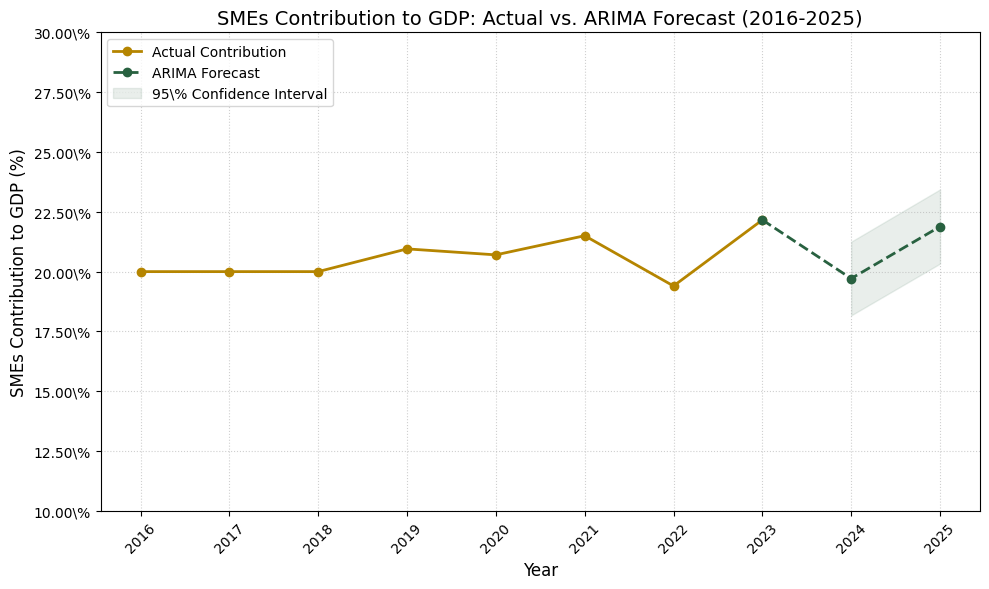

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

#Data Loading and Cleaning ---

# Load data
df = pd.read_csv('VSVS(LIne).csv', header=1)

# Identify the contribution column name (it often contains extra characters/spaces)
contribution_col = [col for col in df.columns if 'SMEs Contribution' in col][0]

df_cleaned = df.dropna(subset=['Year', contribution_col]).copy()
df_cleaned.rename(columns={contribution_col: 'Actual Contribution'}, inplace=True)

# Clean the contribution column (remove '%' and convert to float)
df_cleaned['Actual Contribution'] = df_cleaned['Actual Contribution'].astype(str).str.replace('%', '').astype(float)

# Convert Year to integer and set as index for time series analysis
df_cleaned['Year'] = df_cleaned['Year'].astype(int)
df_ts = df_cleaned.set_index('Year')['Actual Contribution']

#Forecasting with ARIMA (1, 1, 0)

# Define the ARIMA order: p=1 (AR term), d=1 (differencing for trend), q=0 (MA term)
order = (1, 1, 0)

# Train the ARIMA model
model = ARIMA(df_ts, order=order)
model_fit = model.fit()

# Years to forecast: 2024 and 2025 (2 steps)
forecast_steps = 2
last_actual_year = df_ts.index.max()
forecast_index = [last_actual_year + i for i in range(1, forecast_steps + 1)]

# Generate the forecast
forecast_results = model_fit.get_forecast(steps=forecast_steps)
forecasted_contribution = forecast_results.predicted_mean.values
confidence_intervals = forecast_results.conf_int()

# Prepare Plotting Data

df_actual = df_ts.reset_index()
df_actual.columns = ['Year', 'Contribution']

# Prepare forecast line to start from the last actual point
last_actual = df_actual.iloc[-1]
plot_line_start = pd.DataFrame({
    'Year': [last_actual['Year']],
    'Contribution': [last_actual['Contribution']],
})
df_forecast_data = pd.DataFrame({
    'Year': forecast_index,
    'Contribution': forecasted_contribution
})
df_plot_forecast = pd.concat([plot_line_start, df_forecast_data], ignore_index=True)


# Generate the Line Graph

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot 1: Actual Contribution
plt.plot(
    df_actual['Year'],
    df_actual['Contribution'],
    marker='o',
    linestyle='-',
    color='#B58500',
    linewidth=2,
    label='Actual Contribution'
)

# Plot 2: Forecasted Contribution
plt.plot(
    df_plot_forecast['Year'],
    df_plot_forecast['Contribution'],
    marker='o',
    linestyle='--',
    color='#286140',
    linewidth=2,
    label='ARIMA Forecast'
)

# Plot 3: Confidence Intervals (Shaded Area)
plt.fill_between(
    forecast_index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='#286140',
    alpha=0.1,
    label='95\% Confidence Interval'
)


# Annotations and Labels
plt.title('SMEs Contribution to GDP: Actual vs. ARIMA Forecast (2016-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SMEs Contribution to GDP (%)', fontsize=12)

# Set Y-axis range from 10% to 30% (as requested)
plt.ylim(10.0, 30.0)

# Format Y-axis numbers to include the percent sign
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}\%'))

all_years = np.concatenate([df_actual['Year'].unique(), forecast_index])
plt.xticks(all_years, rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

# Set legend to the top left corner (as requested previously)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# In a functional environment, you would save the figure here
plt.savefig('sme_gdp_arima_forecast_10_30.png')


# Summary Table Generation

forecast_values_rounded = forecasted_contribution.round(2)
lower_ci_rounded = confidence_intervals.iloc[:, 0].values.round(2)
upper_ci_rounded = confidence_intervals.iloc[:, 1].values.round(2)

df_forecast_table = pd.DataFrame({
    'Year': forecast_index,
    'Forecasted Contribution (%)': [f'{x:.2f}\%' for x in forecast_values_rounded],
    '95% Lower Bound (%)': [f'{x:.2f}\%' for x in lower_ci_rounded],
    '95% Upper Bound (%)': [f'{x:.2f}\%' for x in upper_ci_rounded]
})

print("\n--- Summary of ARIMA Forecasted Contribution (2024-2025) ---")
print(df_forecast_table.to_markdown(index=False, numalign="left", stralign="left"))